How has the relationship between poverty and fertility rates across U.S. states changed from 2007–2024?

In [151]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from dotenv import load_dotenv

load_dotenv()

CENSUS_API_KEY = os.getenv("CENSUS_API_KEY")

In [152]:
years = list(range(2007, 2025))
years

[2007,
 2008,
 2009,
 2010,
 2011,
 2012,
 2013,
 2014,
 2015,
 2016,
 2017,
 2018,
 2019,
 2020,
 2021,
 2022,
 2023,
 2024]

In [153]:
def find_variables(year):

    url = f"https://api.census.gov/data/{year}/acs/acs1/profile/variables.json"

    response = requests.get(url)
    response.raise_for_status()

    variables = response.json()["variables"]

    fertility_var = None
    poverty_var = None

    for var, info in variables.items():

        label = info.get("label", "")

        # Fertility variable - U.S. profile only
        if (
            var.startswith("DP02_")
            and var.endswith("E")
            and not var.endswith("PE")
            and "FERTILITY" in label
            and "Per 1,000 women 15 to 50 years old" in label
        ):
            fertility_var = var

        # Poverty variable - U.S. profile only
        if (
            var.startswith("DP03_")
            and var.endswith("PE")
            and "BELOW THE POVERTY LEVEL" in label
            and "All people" in label
        ):
            poverty_var = var

    return fertility_var, poverty_var

In [154]:
for year in [2007, 2010, 2015, 2019, 2021, 2024]:

    fertility_var, poverty_var = find_variables(year)

    print(
        year,
        "| Fertility:", fertility_var,
        "| Poverty:", poverty_var
    )

2007 | Fertility: DP02_0039E | Poverty: DP03_0105PE
2010 | Fertility: DP02_0040E | Poverty: DP03_0128PE
2015 | Fertility: DP02_0039E | Poverty: DP03_0128PE
2019 | Fertility: DP02_0040E | Poverty: DP03_0128PE
2021 | Fertility: DP02_0040E | Poverty: DP03_0128PE
2024 | Fertility: DP02_0040E | Poverty: DP03_0128PE


In [155]:
def get_year_data(year):

    fertility_var, poverty_var = find_variables(year)

    fertility_url = (
        f"https://api.census.gov/data/"
        f"{year}/acs/acs1/profile"
    )

    fertility_params = {
        "get": f"NAME,{fertility_var}",
        "for": "state:*",
        "key": CENSUS_API_KEY
    }

    fertility_response = requests.get(
        fertility_url,
        params=fertility_params
    )

    fertility_response.raise_for_status()

    fertility_raw = fertility_response.json()

    fertility = pd.DataFrame(
        fertility_raw[1:],
        columns=fertility_raw[0]
    )

    fertility = fertility.rename(columns={
        "NAME": "state_name",
        fertility_var: "fertility_rate",
        "state": "state_code"
    })

    poverty_url = (
        f"https://api.census.gov/data/"
        f"{year}/acs/acs1"
    )

    poverty_params = {
        "get": "B17001_001E,B17001_002E",
        "for": "state:*",
        "key": CENSUS_API_KEY
    }

    poverty_response = requests.get(
        poverty_url,
        params=poverty_params
    )

    poverty_response.raise_for_status()

    poverty_raw = poverty_response.json()

    poverty = pd.DataFrame(
        poverty_raw[1:],
        columns=poverty_raw[0]
    )

    poverty["total_population"] = pd.to_numeric(
        poverty["B17001_001E"]
    )

    poverty["below_poverty"] = pd.to_numeric(
        poverty["B17001_002E"]
    )

    poverty["poverty_rate"] = (
        poverty["below_poverty"]
        / poverty["total_population"]
        * 100
    )

    df = fertility.merge(
        poverty[["state", "poverty_rate"]],
        left_on="state_code",
        right_on="state"
    )

    df = df.drop(columns=["state"])

    df["year"] = year

    return df

In [156]:
years = [
    2007, 2008, 2009, 2010, 2011,
    2012, 2013, 2014, 2015, 2016,
    2017, 2018, 2019,
    2021, 2022, 2023, 2024
]

all_data = []

for year in years:

    try:
        print("Getting:", year)

        year_data = get_year_data(year)

        all_data.append(year_data)

        print("✓ Worked")

    except Exception as e:

        print("✗ FAILED:", year)
        print(e)

Getting: 2007
✓ Worked
Getting: 2008
✓ Worked
Getting: 2009
✓ Worked
Getting: 2010
✓ Worked
Getting: 2011
✓ Worked
Getting: 2012
✓ Worked
Getting: 2013
✓ Worked
Getting: 2014
✓ Worked
Getting: 2015
✓ Worked
Getting: 2016
✓ Worked
Getting: 2017
✓ Worked
Getting: 2018
✓ Worked
Getting: 2019
✓ Worked
Getting: 2021
✓ Worked
Getting: 2022
✓ Worked
Getting: 2023
✓ Worked
Getting: 2024
✓ Worked


In [157]:
data = pd.concat(all_data, ignore_index=True)

data.head()

,state_name,fertility_rate,state_code,poverty_rate,year
0,Alabama,57,01,16.860684,2007
1,Alaska,65,02,8.944403,2007
2,Arizona,64,04,14.155634,2007
3,Arkansas,57,05,17.867337,2007
4,California,55,06,12.393793,2007


In [158]:
print(data.columns)
print(data.shape)

Index(['state_name', 'fertility_rate', 'state_code', 'poverty_rate', 'year'], dtype='str')
(884, 5)


In [159]:
data = data[
    ~data["state_code"].isin(["11", "72"])
].copy()

In [160]:
data["poverty_rate"] = pd.to_numeric(
    data["poverty_rate"],
    errors="coerce"
)

data["fertility_rate"] = pd.to_numeric(
    data["fertility_rate"],
    errors="coerce"
)

In [161]:
data = data.dropna(
    subset=["poverty_rate", "fertility_rate"]
)

data.head()


,state_name,fertility_rate,state_code,poverty_rate,year
0,Alabama,57,01,16.860684,2007
1,Alaska,65,02,8.944403,2007
2,Arizona,64,04,14.155634,2007
3,Arkansas,57,05,17.867337,2007
4,California,55,06,12.393793,2007


In [162]:
print("Years:")
print(sorted(data["year"].unique()))

print("\nNumber of states:")
print(data["state_name"].nunique())

print("\nMissing values:")
print(data.isnull().sum())

Years:
[np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]

Number of states:
50

Missing values:
state_name        0
fertility_rate    0
state_code        0
poverty_rate      0
year              0
dtype: int64


In [163]:
data.describe()

,fertility_rate,poverty_rate,year
count,850.000000,850.000000,850.000000
mean,48.421176,13.451479,2015.235294
std,13.809371,3.150118,5.222149
min,3.000000,7.075961,2007.000000
25%,46.000000,11.049842,2011.000000
50%,51.000000,12.978223,2015.000000
75%,57.000000,15.766761,2019.000000
max,82.000000,24.153531,2024.000000


In [166]:
correlations = (
    data.groupby("year")
    .apply(lambda g: g["poverty_rate"].corr(g["fertility_rate"]))
    .reset_index(name="correlation")
)

correlations

,year,correlation
0,2007,0.101093
1,2008,0.076678
2,2009,0.176045
3,2010,0.621256
4,2011,0.641758
5,2012,0.602560
6,2013,0.019884
7,2014,-0.181019
8,2015,-0.079179
9,2016,-0.010987


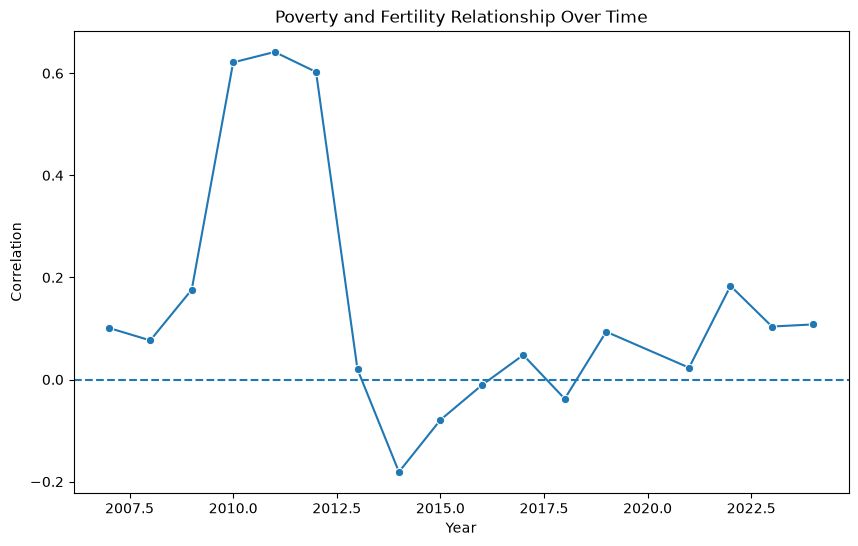

In [170]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=correlations,
    x="year",
    y="correlation",
    marker="o"
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Poverty and Fertility Relationship Over Time")
plt.xlabel("Year")
plt.ylabel("Correlation")

plt.show()

In [168]:
yearly_average = (
    data.groupby("year")["fertility_rate"]
    .mean()
    .reset_index()
)

yearly_average

,year,fertility_rate
0,2007,55.42
1,2008,59.08
2,2009,58.32
3,2010,25.96
4,2011,22.46
5,2012,21.54
6,2013,52.86
7,2014,53.36
8,2015,52.78
9,2016,52.88


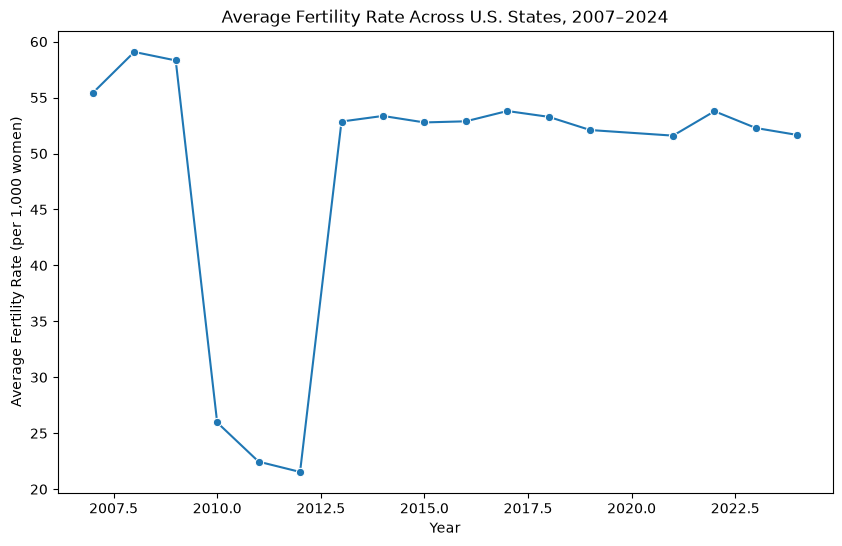

In [169]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=yearly_average,
    x="year",
    y="fertility_rate",
    marker="o"
)

plt.title("Average Fertility Rate Across U.S. States, 2007–2024")
plt.xlabel("Year")
plt.ylabel("Average Fertility Rate (per 1,000 women)")

plt.show()